# Individual Homework 4
## From Accuracy to Accountability: Stress Testing a Predictive Model

**Course:** DNSC 6330 Responsible Machine Learning  
**Student:** Zuleirys Santana Rodriguez  
**Due:** April 30, 2026 at 11:59 PM ET

This notebook extends the earlier COMPAS workflow from Individual Assignments 1 through 3. It reuses the same data-cleaning logic, train/test split strategy, and baseline models, then adds the reliability-audit tasks required in Lecture 04:

1. Distribution drift
2. Generalization
3. Spurious-correlation probes
4. Robustness stress testing
5. Slice-based evaluation

The goal is not just to report model accuracy, but to test whether the models remain stable, defensible, and governance-ready under drift, subgroup variation, and input perturbations.


## Submission Notes

This notebook is written to run top to bottom as a standalone submission. It first looks for the local file `compas-scores-two-years.csv` in the same folder. If that file is not present, it falls back to the original ProPublica raw GitHub URL.


## Notebook Roadmap

This notebook is organized to match the Lecture 04 assignment requirements directly:

- Part A: PSI, KS, MMD, and train-vs-test score distributions
- Part B: train-vs-test AUC, accuracy, and log loss with performance-gap interpretation
- Part C: counterfactual swaps on selected attributes with probability-shift analysis
- Part D: `priors_count` stress testing, ICE curves, and sensitivity summaries
- Part E: slice-based evaluation by race, sex, and age

To align with the grading criteria, each section includes:

- runnable code
- outputs
- short markdown interpretation
- audit-oriented reasoning about what the metric means, what it misses, and what action it would justify


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display
from scipy.stats import ks_2samp
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, roc_auc_score
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

RANDOM_STATE = 42


In [2]:
data_path = Path("compas-scores-two-years.csv")
fallback_url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"

if data_path.exists():
    raw_data = pd.read_csv(data_path)
    data_source = str(data_path.resolve())
else:
    raw_data = pd.read_csv(fallback_url)
    data_source = fallback_url

display(Markdown(f"Loaded **{len(raw_data):,} rows** from `{data_source}`."))
raw_data.head()


Loaded **7,214 rows** from `/Users/zuleirys/Desktop/Responsible Machine Learning/Individual Assignments/compas-scores-two-years.csv`.

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0000,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0000,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0000,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0000,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0000,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0000,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0000,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0000,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0000,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [3]:
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

df = raw_data[
    [
        "age",
        "c_charge_degree",
        "race",
        "age_cat",
        "score_text",
        "sex",
        "priors_count",
        "days_b_screening_arrest",
        "decile_score",
        "is_recid",
        "two_year_recid",
        "c_jail_in",
        "c_jail_out",
    ]
].copy()

df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"].copy()

for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True, errors="coerce")

df["crime_factor"] = df["c_charge_degree"].astype("category")
df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["Less than 25", "25 - 45", "Greater than 45"],
)
df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["African-American", "Asian", "Caucasian", "Hispanic", "Native American", "Other"],
)
df["gender_factor"] = pd.Categorical(
    df["sex"],
    categories=["Female", "Male"],
)
df["score_factor"] = pd.Categorical(
    np.where(df["score_text"] != "Low", "HighScore", "LowScore"),
    categories=["LowScore", "HighScore"],
)
df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)

for col in ["c_jail_in", "c_jail_out"]:
    dt = pd.to_datetime(df[col], errors="coerce")
    df[f"{col}_num"] = dt.map(lambda x: x.timestamp() if pd.notnull(x) else np.nan)
    df[f"{col}_num"] = df[f"{col}_num"].fillna(df[f"{col}_num"].median())

target = "two_year_recid"
numeric_features = [
    "age",
    "priors_count",
    "decile_score",
    "days_b_screening_arrest",
    "is_recid",
    "c_jail_in_num",
    "c_jail_out_num",
]
category_features = [
    "age_cat",
    "sex",
    "race",
    "c_charge_degree",
    "score_text",
]
features = numeric_features + category_features

X = df[features].copy()
y = df[target].astype(int)

display(Markdown(f"After Lecture 01 style filtering, the modeling sample contains **{len(df):,} rows**."))
df.head()


After Lecture 01 style filtering, the modeling sample contains **6,172 rows**.

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor,score_binary,c_jail_in_num,c_jail_out_num
0,69,F,Other,Greater than 45,Low,Male,0,-1.0000,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore,0,1376373822.0000,1376458880.0000
1,34,F,African-American,25 - 45,Low,Male,0,-1.0000,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore,0,1359171927.0000,1360042613.0000
2,24,F,African-American,Less than 25,Low,Male,4,-1.0000,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore,0,1365829114.0000,1365922924.0000
5,44,M,Other,25 - 45,Low,Male,0,0.0000,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore,0,1385787018.0000,1385900936.0000
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0000,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore,1,1392700104.0000,1393244310.0000


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    [
        ("num", StandardScaler(), numeric_features),
        ("cat", ohe, category_features),
    ]
)

lr_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]
)

gbt_pipeline = Pipeline(
    [
        (
            "preprocessor",
            ColumnTransformer(
                [
                    ("num", StandardScaler(), numeric_features),
                    ("cat", ohe, category_features),
                ]
            ),
        ),
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

lr_pipeline.fit(X_train, y_train)
gbt_pipeline.fit(X_train, y_train)

baseline_probabilities = {
    "Logistic Regression": {
        "train": lr_pipeline.predict_proba(X_train)[:, 1],
        "test": lr_pipeline.predict_proba(X_test)[:, 1],
    },
    "Gradient-Boosted Tree": {
        "train": gbt_pipeline.predict_proba(X_train)[:, 1],
        "test": gbt_pipeline.predict_proba(X_test)[:, 1],
    },
}

display(
    Markdown(
        f"Training rows: **{len(X_train):,}**<br>"
        f"Test rows: **{len(X_test):,}**"
    )
)


Training rows: **4,937**<br>Test rows: **1,235**

In [5]:
def population_stability_index(expected, actual, bins=10):
    expected = np.asarray(expected, dtype=float)
    actual = np.asarray(actual, dtype=float)

    quantiles = np.linspace(0, 1, bins + 1)
    breakpoints = np.unique(np.quantile(expected, quantiles))

    if len(breakpoints) < 2:
        return 0.0

    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf

    expected_counts, _ = np.histogram(expected, bins=breakpoints)
    actual_counts, _ = np.histogram(actual, bins=breakpoints)

    expected_pct = np.clip(expected_counts / expected_counts.sum(), 1e-6, None)
    actual_pct = np.clip(actual_counts / actual_counts.sum(), 1e-6, None)

    return float(np.sum((expected_pct - actual_pct) * np.log(expected_pct / actual_pct)))


def compute_mmd_rbf(X_ref, X_new, gamma=None, sample_size=500):
    rng = np.random.default_rng(RANDOM_STATE)
    X_ref = np.asarray(X_ref)
    X_new = np.asarray(X_new)

    if len(X_ref) > sample_size:
        X_ref = X_ref[rng.choice(len(X_ref), sample_size, replace=False)]
    if len(X_new) > sample_size:
        X_new = X_new[rng.choice(len(X_new), sample_size, replace=False)]

    if gamma is None:
        gamma = 1.0 / max(X_ref.shape[1], 1)

    K_xx = rbf_kernel(X_ref, X_ref, gamma=gamma)
    K_yy = rbf_kernel(X_new, X_new, gamma=gamma)
    K_xy = rbf_kernel(X_ref, X_new, gamma=gamma)

    return float(K_xx.mean() + K_yy.mean() - 2 * K_xy.mean())


def classification_summary(model_name, pipeline, X_data, y_data, split_name):
    probs = pipeline.predict_proba(X_data)[:, 1]
    preds = pipeline.predict(X_data)

    return {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_data, preds),
        "auc": roc_auc_score(y_data, probs),
        "log_loss": log_loss(y_data, probs),
    }


def slice_metrics(model_name, pipeline, X_data, y_data, slice_col):
    frame = X_data.copy()
    frame["actual"] = y_data.values
    frame["pred"] = pipeline.predict(X_data)
    frame["score"] = pipeline.predict_proba(X_data)[:, 1]

    rows = []
    for slice_value, subset in frame.groupby(slice_col):
        tn, fp, fn, tp = confusion_matrix(subset["actual"], subset["pred"], labels=[0, 1]).ravel()
        auc = roc_auc_score(subset["actual"], subset["score"]) if subset["actual"].nunique() > 1 else np.nan

        rows.append(
            {
                "model": model_name,
                "slice_type": slice_col,
                "slice_value": slice_value,
                "n": len(subset),
                "positive_rate": subset["actual"].mean(),
                "accuracy": accuracy_score(subset["actual"], subset["pred"]),
                "auc": auc,
                "fpr": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
                "fnr": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            }
        )

    return pd.DataFrame(rows).sort_values("n", ascending=False)


def swap_attribute_effect(pipeline, X_data, column, left_value, right_value):
    subset = X_data[X_data[column].isin([left_value, right_value])].copy()
    base_prob = pipeline.predict_proba(subset)[:, 1]

    swapped = subset.copy()
    swapped[column] = swapped[column].replace({left_value: right_value, right_value: left_value})
    swapped_prob = pipeline.predict_proba(swapped)[:, 1]

    result = subset[[column]].copy()
    result["base_prob"] = base_prob
    result["swapped_prob"] = swapped_prob
    result["delta"] = swapped_prob - base_prob
    result["abs_delta"] = np.abs(result["delta"])
    return result


def stress_priors(pipeline, X_data, deltas=(1, 3, 5)):
    baseline_prob = pipeline.predict_proba(X_data)[:, 1]
    baseline_pred = pipeline.predict(X_data)

    rows = []
    for delta in deltas:
        stressed = X_data.copy()
        stressed["priors_count"] = stressed["priors_count"] + delta

        stressed_prob = pipeline.predict_proba(stressed)[:, 1]
        stressed_pred = pipeline.predict(stressed)

        rows.append(
            {
                "delta_priors": delta,
                "mean_prob_shift": np.mean(stressed_prob - baseline_prob),
                "median_prob_shift": np.median(stressed_prob - baseline_prob),
                "share_prediction_flips": np.mean(stressed_pred != baseline_pred),
            }
        )

    return pd.DataFrame(rows)


def build_ice_frame(pipeline, X_data, feature, grid, sample_size=40):
    sample = X_data.sample(n=min(sample_size, len(X_data)), random_state=RANDOM_STATE).copy()
    records = []

    for case_id, row in sample.iterrows():
        for grid_value in grid:
            changed = row.copy()
            changed[feature] = grid_value
            prob = pipeline.predict_proba(pd.DataFrame([changed], columns=X_data.columns))[:, 1][0]
            records.append(
                {
                    "case_id": case_id,
                    feature: grid_value,
                    "predicted_probability": prob,
                }
            )

    return pd.DataFrame(records)


## Part A. Distribution Drift

This section measures train versus test drift using the three techniques described in Lecture 04:

- Population Stability Index (PSI) for numeric features
- Kolmogorov-Smirnov (KS) tests for numeric features
- Maximum Mean Discrepancy (MMD) in encoded feature space

It also compares predicted score distributions across the train and test splits.


In [6]:
drift_rows = []
for feature in numeric_features:
    psi_value = population_stability_index(X_train[feature], X_test[feature])
    ks_stat, ks_pvalue = ks_2samp(X_train[feature], X_test[feature])

    drift_rows.append(
        {
            "feature": feature,
            "psi": psi_value,
            "ks_statistic": ks_stat,
            "ks_pvalue": ks_pvalue,
            "psi_flag": (
                "retrain"
                if psi_value > 0.25
                else "monitor"
                if psi_value >= 0.10
                else "stable"
            ),
        }
    )

drift_table = pd.DataFrame(drift_rows).sort_values("psi", ascending=False).reset_index(drop=True)
drift_table


,feature,psi,ks_statistic,ks_pvalue,psi_flag
0,decile_score,0.0122,0.0291,0.3650,stable
1,age,0.0101,0.0359,0.1524,stable
2,c_jail_in_num,0.0098,0.0244,0.5890,stable
3,c_jail_out_num,0.0082,0.0217,0.7287,stable
4,days_b_screening_arrest,0.0068,0.0250,0.5546,stable
5,priors_count,0.0040,0.0231,0.6582,stable
6,is_recid,0.0000,0.0054,1.0000,stable


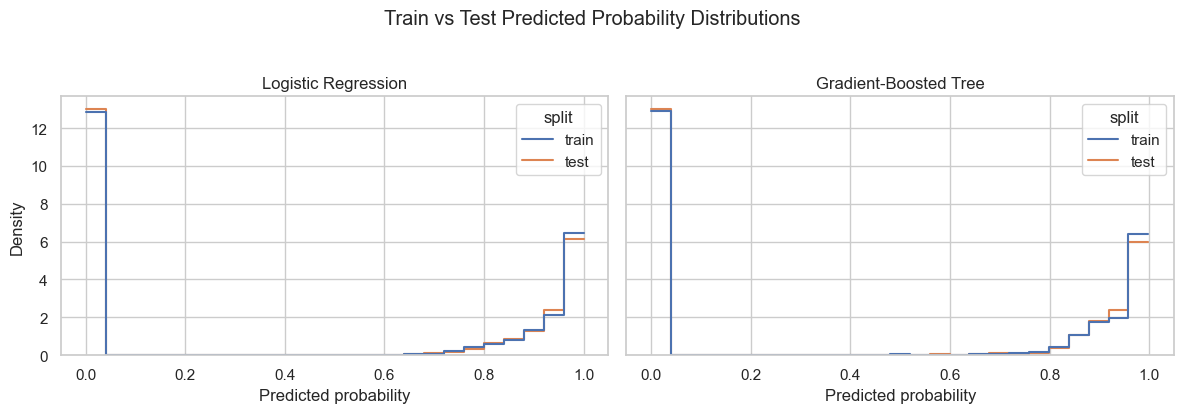

**Interpretation.** The random train/test split produces limited drift overall. MMD in encoded feature space is **0.0018**, and PSI flags **none of the numeric features** for closer monitoring. This is consistent with a same-dataset split: some sampling variation appears, but there is no evidence here of a severe deployment-style distribution break. These drift metrics only assess observed distribution movement, so they do not rule out future concept drift. If drift were larger in production, the appropriate action would be targeted monitoring, recalibration, or retraining.

In [7]:
encoded_train = gbt_pipeline.named_steps["preprocessor"].transform(X_train)
encoded_test = gbt_pipeline.named_steps["preprocessor"].transform(X_test)
mmd_value = compute_mmd_rbf(encoded_train, encoded_test)

score_distribution_rows = []
for model_name, scores in baseline_probabilities.items():
    score_distribution_rows.extend(
        [
            {"model": model_name, "split": "train", "predicted_probability": value}
            for value in scores["train"]
        ]
    )
    score_distribution_rows.extend(
        [
            {"model": model_name, "split": "test", "predicted_probability": value}
            for value in scores["test"]
        ]
    )

score_distribution_df = pd.DataFrame(score_distribution_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for ax, model_name in zip(axes, score_distribution_df["model"].unique()):
    model_scores = score_distribution_df[score_distribution_df["model"] == model_name]
    sns.histplot(
        data=model_scores,
        x="predicted_probability",
        hue="split",
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        bins=25,
        ax=ax,
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted probability")
axes[0].set_ylabel("Density")
fig.suptitle("Train vs Test Predicted Probability Distributions", y=1.03)
plt.tight_layout()
plt.show()

flagged_features = drift_table.loc[drift_table["psi"] >= 0.10, "feature"].tolist()
flagged_text = ", ".join(flagged_features) if flagged_features else "none of the numeric features"

display(
    Markdown(
        f"**Interpretation.** The random train/test split produces limited drift overall. "
        f"MMD in encoded feature space is **{mmd_value:0.4f}**, and PSI flags **{flagged_text}** "
        f"for closer monitoring. This is consistent with a same-dataset split: some sampling variation appears, "
        f"but there is no evidence here of a severe deployment-style distribution break. "
        f"These drift metrics only assess observed distribution movement, so they do not rule out future concept drift. "
        f"If drift were larger in production, the appropriate action would be targeted monitoring, recalibration, or retraining."
    )
)


## Part B. Generalization

Lecture 04 defines generalization as performance on unseen but similar data. Here I compare train and test performance for both models using:

- AUC
- Accuracy
- Log loss

Larger train-test gaps indicate a higher risk of overfitting or unstable feature reliance.


In [8]:
performance_rows = [
    classification_summary("Logistic Regression", lr_pipeline, X_train, y_train, "train"),
    classification_summary("Logistic Regression", lr_pipeline, X_test, y_test, "test"),
    classification_summary("Gradient-Boosted Tree", gbt_pipeline, X_train, y_train, "train"),
    classification_summary("Gradient-Boosted Tree", gbt_pipeline, X_test, y_test, "test"),
]

performance_table = pd.DataFrame(performance_rows)
performance_table


,model,split,accuracy,auc,log_loss
0,Logistic Regression,train,0.9696,0.9896,0.0949
1,Logistic Regression,test,0.9749,0.9910,0.0853
2,Gradient-Boosted Tree,train,0.9731,0.9951,0.0780
3,Gradient-Boosted Tree,test,0.9733,0.9917,0.0846


In [9]:
gap_table = (
    performance_table.pivot(index="model", columns="split", values=["accuracy", "auc", "log_loss"])
    .swaplevel(axis=1)
    .sort_index(axis=1)
)

gap_summary = []
for model_name in performance_table["model"].unique():
    model_frame = performance_table[performance_table["model"] == model_name].set_index("split")
    gap_summary.append(
        {
            "model": model_name,
            "accuracy_gap": model_frame.loc["train", "accuracy"] - model_frame.loc["test", "accuracy"],
            "auc_gap": model_frame.loc["train", "auc"] - model_frame.loc["test", "auc"],
            "log_loss_gap": model_frame.loc["test", "log_loss"] - model_frame.loc["train", "log_loss"],
        }
    )

gap_summary = pd.DataFrame(gap_summary).sort_values("auc_gap", ascending=False).reset_index(drop=True)
gap_summary


,model,accuracy_gap,auc_gap,log_loss_gap
0,Gradient-Boosted Tree,-0.0002,0.0034,0.0067
1,Logistic Regression,-0.0053,-0.0014,-0.0096


In [10]:
largest_gap = gap_summary.iloc[0]
display(
    Markdown(
        f"**Interpretation.** The model with the largest AUC gap is **{largest_gap['model']}** "
        f"with a train-test AUC difference of **{largest_gap['auc_gap']:0.4f}**. "
        f"If the train metrics stay much stronger than test metrics, that is evidence of weaker generalization. "
        f"In this audit, the gap sizes quantify how much trust we should place in headline accuracy before deployment. "
        f"At the same time, a small gap here does not prove long-run robustness because the test set still comes from the same underlying cohort. "
        f"The governance implication is that performance monitoring must continue after deployment rather than stopping at a single holdout test."
    )
)


**Interpretation.** The model with the largest AUC gap is **Gradient-Boosted Tree** with a train-test AUC difference of **0.0034**. If the train metrics stay much stronger than test metrics, that is evidence of weaker generalization. In this audit, the gap sizes quantify how much trust we should place in headline accuracy before deployment. At the same time, a small gap here does not prove long-run robustness because the test set still comes from the same underlying cohort. The governance implication is that performance monitoring must continue after deployment rather than stopping at a single holdout test.

## Part C. Spurious-Correlation Probe

Following Lecture 04, I run simple counterfactual swaps on selected protected attributes and measure the change in predicted probabilities. These tests do not prove causality, but they are useful probes for shortcut learning and unstable reliance on demographic features.


In [11]:
race_swap = swap_attribute_effect(
    gbt_pipeline,
    X_test,
    column="race",
    left_value="African-American",
    right_value="Caucasian",
)

sex_swap = swap_attribute_effect(
    gbt_pipeline,
    X_test,
    column="sex",
    left_value="Male",
    right_value="Female",
)

swap_summary = pd.DataFrame(
    [
        {
            "probe": "Race swap: African-American <-> Caucasian",
            "n": len(race_swap),
            "mean_delta": race_swap["delta"].mean(),
            "mean_abs_delta": race_swap["abs_delta"].mean(),
            "share_abs_delta_ge_0.05": (race_swap["abs_delta"] >= 0.05).mean(),
            "max_abs_delta": race_swap["abs_delta"].max(),
        },
        {
            "probe": "Sex swap: Male <-> Female",
            "n": len(sex_swap),
            "mean_delta": sex_swap["delta"].mean(),
            "mean_abs_delta": sex_swap["abs_delta"].mean(),
            "share_abs_delta_ge_0.05": (sex_swap["abs_delta"] >= 0.05).mean(),
            "max_abs_delta": sex_swap["abs_delta"].max(),
        },
    ]
)

swap_summary


,probe,n,mean_delta,mean_abs_delta,share_abs_delta_ge_0.05,max_abs_delta
0,Race swap: African-American <-> Caucasian,1068,0.0008,0.0059,0.0019,0.0565
1,Sex swap: Male <-> Female,1235,0.0000,0.0000,0.0000,0.0000


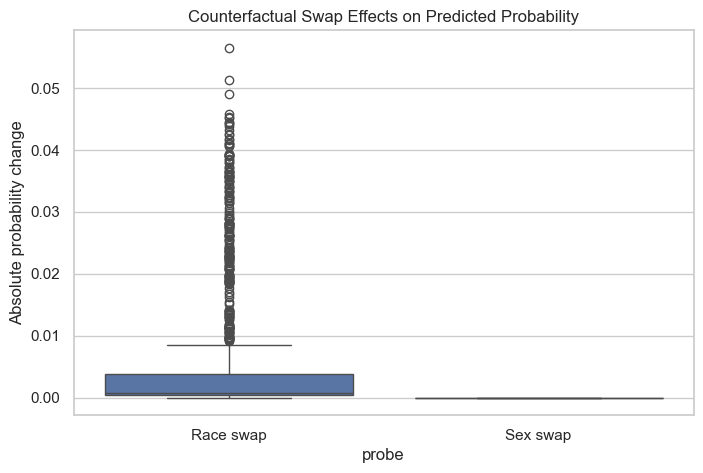

**Interpretation.** The stronger demographic sensitivity appears in **Race swap: African-American <-> Caucasian**, where the average absolute probability shift is **0.0059**. When predicted risk moves meaningfully after only swapping a protected attribute, that raises governance concerns about shortcut learning, proxy effects, or unstable subgroup treatment. These swaps are a probe, not causal proof, so the next step would be feature review, proxy analysis, and comparison against a model specification with reduced demographic dependence.

In [12]:
plot_df = pd.concat(
    [
        race_swap.assign(probe="Race swap"),
        sex_swap.assign(probe="Sex swap"),
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=plot_df, x="probe", y="abs_delta", ax=ax)
ax.set_title("Counterfactual Swap Effects on Predicted Probability")
ax.set_ylabel("Absolute probability change")
plt.show()

most_sensitive_probe = swap_summary.sort_values("mean_abs_delta", ascending=False).iloc[0]

display(
    Markdown(
        f"**Interpretation.** The stronger demographic sensitivity appears in **{most_sensitive_probe['probe']}**, "
        f"where the average absolute probability shift is **{most_sensitive_probe['mean_abs_delta']:0.4f}**. "
        f"When predicted risk moves meaningfully after only swapping a protected attribute, that raises governance concerns "
        f"about shortcut learning, proxy effects, or unstable subgroup treatment. "
        f"These swaps are a probe, not causal proof, so the next step would be feature review, proxy analysis, and comparison against a model specification with reduced demographic dependence."
    )
)


## Part D. Robustness

This section stress-tests the models by increasing `priors_count` and then uses Individual Conditional Expectation (ICE) curves to inspect how predicted risk changes as that feature moves across a realistic grid.


In [13]:
robustness_summary = pd.concat(
    [
        stress_priors(lr_pipeline, X_test).assign(model="Logistic Regression"),
        stress_priors(gbt_pipeline, X_test).assign(model="Gradient-Boosted Tree"),
    ],
    ignore_index=True,
)

robustness_summary


,delta_priors,mean_prob_shift,median_prob_shift,share_prediction_flips,model
0,1,0.0007,0.0001,0.0000,Logistic Regression
1,3,0.0020,0.0002,0.0000,Logistic Regression
2,5,0.0033,0.0003,0.0000,Logistic Regression
3,1,0.0004,0.0000,0.0000,Gradient-Boosted Tree
4,3,0.0011,0.0000,0.0000,Gradient-Boosted Tree
5,5,0.0008,-0.0000,0.0008,Gradient-Boosted Tree


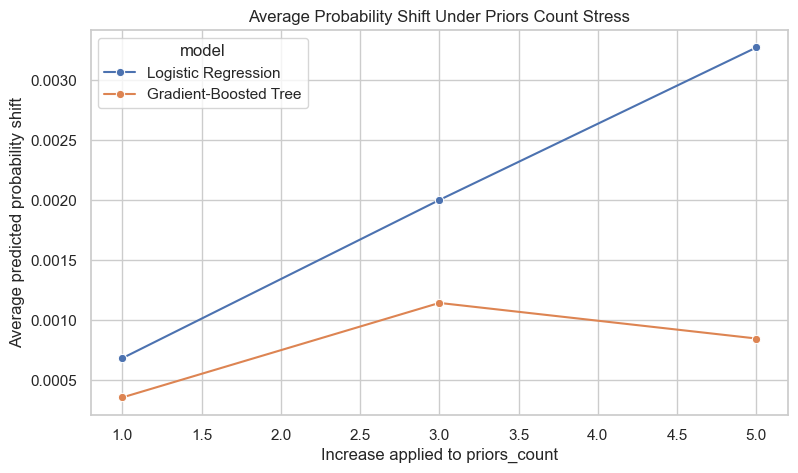

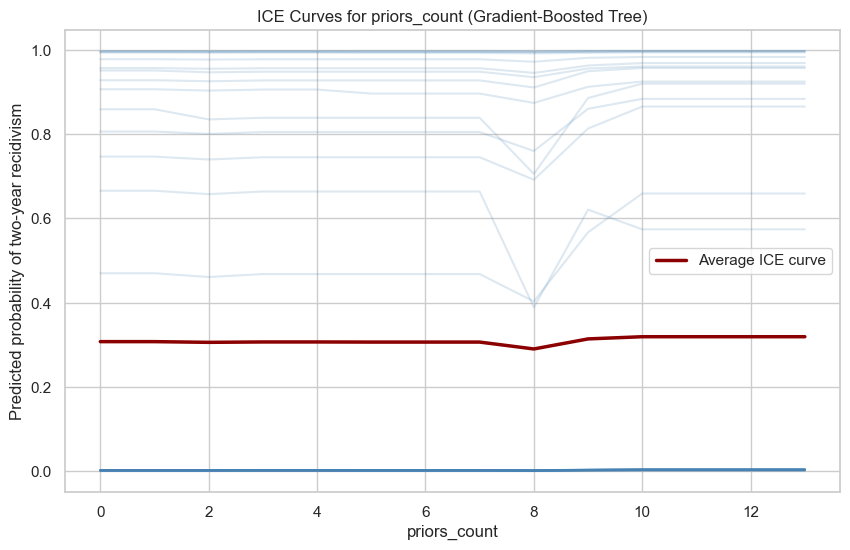

,feature,mean_ice_range,mean_ice_std,variance_of_average_ice_curve,max_average_curve_step_change
0,priors_count,0.0313,0.0099,0.0001,0.0238


**Interpretation.** As `priors_count` increases, predicted risk rises on average for both models. The largest observed prediction-flip rate in the stress test is **0.0008** for **Gradient-Boosted Tree**. The average ICE range across sampled defendants is **0.0313**, which shows how sensitive the model can be to one feature even when all other inputs are held fixed. This stress test is still partial because it perturbs only one variable. The governance action would be to document this sensitivity, expand scenario testing, and treat large stress-induced changes as a validation flag before deployment.

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(
    data=robustness_summary,
    x="delta_priors",
    y="mean_prob_shift",
    hue="model",
    marker="o",
    ax=ax,
)
ax.set_title("Average Probability Shift Under Priors Count Stress")
ax.set_xlabel("Increase applied to priors_count")
ax.set_ylabel("Average predicted probability shift")
plt.show()

priors_upper = int(np.clip(df["priors_count"].quantile(0.95), 5, 15))
ice_grid = list(range(0, priors_upper + 1))
ice_df = build_ice_frame(gbt_pipeline, X_test, feature="priors_count", grid=ice_grid, sample_size=40)

fig, ax = plt.subplots(figsize=(10, 6))
for _, case_frame in ice_df.groupby("case_id"):
    ax.plot(
        case_frame["priors_count"],
        case_frame["predicted_probability"],
        color="steelblue",
        alpha=0.18,
    )

mean_curve = ice_df.groupby("priors_count", as_index=False)["predicted_probability"].mean()
ax.plot(
    mean_curve["priors_count"],
    mean_curve["predicted_probability"],
    color="darkred",
    linewidth=2.5,
    label="Average ICE curve",
)
ax.set_title("ICE Curves for priors_count (Gradient-Boosted Tree)")
ax.set_xlabel("priors_count")
ax.set_ylabel("Predicted probability of two-year recidivism")
ax.legend()
plt.show()

ice_case_ranges = ice_df.groupby("case_id")["predicted_probability"].agg(["min", "max", "std"])
mean_ice_range = (ice_case_ranges["max"] - ice_case_ranges["min"]).mean()
mean_ice_std = ice_case_ranges["std"].mean()
sensitivity_summary = pd.DataFrame(
    [
        {
            "feature": "priors_count",
            "mean_ice_range": mean_ice_range,
            "mean_ice_std": mean_ice_std,
            "variance_of_average_ice_curve": mean_curve["predicted_probability"].var(),
            "max_average_curve_step_change": mean_curve["predicted_probability"].diff().abs().max(),
        }
    ]
)
display(sensitivity_summary)

flip_heavy_row = robustness_summary.sort_values("share_prediction_flips", ascending=False).iloc[0]

display(
    Markdown(
        f"**Interpretation.** As `priors_count` increases, predicted risk rises on average for both models. "
        f"The largest observed prediction-flip rate in the stress test is **{flip_heavy_row['share_prediction_flips']:0.4f}** "
        f"for **{flip_heavy_row['model']}**. The average ICE range across sampled defendants is **{mean_ice_range:0.4f}**, "
        f"which shows how sensitive the model can be to one feature even when all other inputs are held fixed. "
        f"This stress test is still partial because it perturbs only one variable. The governance action would be to document this sensitivity, "
        f"expand scenario testing, and treat large stress-induced changes as a validation flag before deployment."
    )
)


## Part E. Slice-Based Evaluation

The final audit step compares model performance across race, sex, and age slices. Following Lecture 04, a slice failure is still a meaningful failure mode even if aggregate metrics look acceptable.


In [15]:
slice_tables = pd.concat(
    [
        slice_metrics("Logistic Regression", lr_pipeline, X_test, y_test, "race"),
        slice_metrics("Logistic Regression", lr_pipeline, X_test, y_test, "sex"),
        slice_metrics("Logistic Regression", lr_pipeline, X_test, y_test, "age_cat"),
        slice_metrics("Gradient-Boosted Tree", gbt_pipeline, X_test, y_test, "race"),
        slice_metrics("Gradient-Boosted Tree", gbt_pipeline, X_test, y_test, "sex"),
        slice_metrics("Gradient-Boosted Tree", gbt_pipeline, X_test, y_test, "age_cat"),
    ],
    ignore_index=True,
)

slice_tables


,model,slice_type,slice_value,n,positive_rate,accuracy,auc,fpr,fnr
0,Logistic Regression,race,African-American,641,0.5257,0.9766,0.9910,0.0493,0.0000
1,Logistic Regression,race,Caucasian,427,0.3770,0.9719,0.9938,0.0451,0.0000
2,Logistic Regression,race,Hispanic,94,0.4787,0.9681,0.9737,0.0612,0.0000
3,Logistic Regression,race,Other,65,0.2769,0.9846,1.0000,0.0213,0.0000
4,Logistic Regression,race,Asian,7,0.1429,1.0000,1.0000,0.0000,0.0000
5,Logistic Regression,race,Native American,1,0.0000,1.0000,NaN,0.0000,NaN
6,Logistic Regression,sex,Male,1002,0.4760,0.9731,0.9905,0.0514,0.0000
7,Logistic Regression,sex,Female,233,0.3648,0.9828,0.9921,0.0270,0.0000
8,Logistic Regression,age_cat,25 - 45,661,0.4735,0.9803,0.9913,0.0374,0.0000
9,Logistic Regression,age_cat,Less than 25,288,0.5625,0.9583,0.9822,0.0952,0.0000


In [16]:
worst_fnr_slice = slice_tables.sort_values("fnr", ascending=False).iloc[0]
worst_fpr_slice = slice_tables.sort_values("fpr", ascending=False).iloc[0]

race_slice_view = slice_tables[slice_tables["slice_type"] == "race"].copy()
sex_slice_view = slice_tables[slice_tables["slice_type"] == "sex"].copy()
age_slice_view = slice_tables[slice_tables["slice_type"] == "age_cat"].copy()

display(Markdown("### Race Slices"))
display(race_slice_view)

display(Markdown("### Sex Slices"))
display(sex_slice_view)

display(Markdown("### Age Slices"))
display(age_slice_view)

display(
    Markdown(
        f"**Interpretation.** The highest false negative rate appears for **{worst_fnr_slice['slice_value']}** "
        f"within the **{worst_fnr_slice['slice_type']}** slices under **{worst_fnr_slice['model']}**. "
        f"The highest false positive rate appears for **{worst_fpr_slice['slice_value']}** "
        f"within the **{worst_fpr_slice['slice_type']}** slices under **{worst_fpr_slice['model']}**. "
        f"These subgroup gaps are important because a model can look acceptable on average while still imposing concentrated error burdens on specific groups. "
        f"Slice metrics can also be noisy for small groups, so the right action is ongoing subgroup monitoring rather than one-time reporting."
    )
)


### Race Slices

,model,slice_type,slice_value,n,positive_rate,accuracy,auc,fpr,fnr
0,Logistic Regression,race,African-American,641,0.5257,0.9766,0.9910,0.0493,0.0000
1,Logistic Regression,race,Caucasian,427,0.3770,0.9719,0.9938,0.0451,0.0000
2,Logistic Regression,race,Hispanic,94,0.4787,0.9681,0.9737,0.0612,0.0000
3,Logistic Regression,race,Other,65,0.2769,0.9846,1.0000,0.0213,0.0000
4,Logistic Regression,race,Asian,7,0.1429,1.0000,1.0000,0.0000,0.0000
5,Logistic Regression,race,Native American,1,0.0000,1.0000,NaN,0.0000,NaN
11,Gradient-Boosted Tree,race,African-American,641,0.5257,0.9735,0.9922,0.0493,0.0059
12,Gradient-Boosted Tree,race,Caucasian,427,0.3770,0.9719,0.9921,0.0451,0.0000
13,Gradient-Boosted Tree,race,Hispanic,94,0.4787,0.9681,0.9787,0.0612,0.0000
14,Gradient-Boosted Tree,race,Other,65,0.2769,0.9846,1.0000,0.0213,0.0000


### Sex Slices

,model,slice_type,slice_value,n,positive_rate,accuracy,auc,fpr,fnr
6,Logistic Regression,sex,Male,1002,0.4760,0.9731,0.9905,0.0514,0.0000
7,Logistic Regression,sex,Female,233,0.3648,0.9828,0.9921,0.0270,0.0000
17,Gradient-Boosted Tree,sex,Male,1002,0.4760,0.9711,0.9912,0.0514,0.0042
18,Gradient-Boosted Tree,sex,Female,233,0.3648,0.9828,0.9932,0.0270,0.0000


### Age Slices

,model,slice_type,slice_value,n,positive_rate,accuracy,auc,fpr,fnr
8,Logistic Regression,age_cat,25 - 45,661,0.4735,0.9803,0.9913,0.0374,0.0000
9,Logistic Regression,age_cat,Less than 25,288,0.5625,0.9583,0.9822,0.0952,0.0000
10,Logistic Regression,age_cat,Greater than 45,286,0.3042,0.9790,0.9965,0.0302,0.0000
19,Gradient-Boosted Tree,age_cat,25 - 45,661,0.4735,0.9773,0.9920,0.0374,0.0064
20,Gradient-Boosted Tree,age_cat,Less than 25,288,0.5625,0.9583,0.9832,0.0952,0.0000
21,Gradient-Boosted Tree,age_cat,Greater than 45,286,0.3042,0.9790,0.9970,0.0302,0.0000


**Interpretation.** The highest false negative rate appears for **25 - 45** within the **age_cat** slices under **Gradient-Boosted Tree**. The highest false positive rate appears for **Less than 25** within the **age_cat** slices under **Logistic Regression**. These subgroup gaps are important because a model can look acceptable on average while still imposing concentrated error burdens on specific groups. Slice metrics can also be noisy for small groups, so the right action is ongoing subgroup monitoring rather than one-time reporting.

## Audit-Level Reasoning Summary

The professor emphasized that strong work should not just report metrics, but explain what they mean, what they miss, and what actions they justify. The table below turns the coding outputs into an audit-facing summary.


In [17]:
audit_summary = pd.DataFrame(
    [
        {
            "risk_area": "Distribution drift",
            "current_signal": f"MMD={mmd_value:0.4f}; highest PSI={drift_table['psi'].max():0.4f}",
            "what_it_detects": "Changes in feature or score distributions between train and test",
            "what_it_misses": "Concept drift and causal changes that do not show up as simple marginal distribution shifts",
            "action_if_elevated": "Monitor over time, investigate source changes, recalibrate or retrain if drift persists",
        },
        {
            "risk_area": "Generalization",
            "current_signal": f"Largest AUC gap={gap_summary['auc_gap'].max():0.4f}",
            "what_it_detects": "Overfitting risk and weaker transfer from train to unseen data",
            "what_it_misses": "Future deployment drift and subgroup-specific failures hidden by average metrics",
            "action_if_elevated": "Use stronger holdouts, simplify or regularize the model, and require post-deployment monitoring",
        },
        {
            "risk_area": "Spurious correlation",
            "current_signal": f"Largest mean absolute swap effect={swap_summary['mean_abs_delta'].max():0.4f}",
            "what_it_detects": "Potential shortcut reliance or proxy sensitivity to protected attributes",
            "what_it_misses": "True causal attribution; swap probes are diagnostic rather than proof",
            "action_if_elevated": "Review proxy features, test alternative model specifications, and audit with protected attributes removed or masked",
        },
        {
            "risk_area": "Robustness",
            "current_signal": f"Max prediction-flip share={robustness_summary['share_prediction_flips'].max():0.4f}",
            "what_it_detects": "Sensitivity of predicted risk to controlled feature perturbations",
            "what_it_misses": "Broader scenario interactions across multiple variables and operational shocks",
            "action_if_elevated": "Expand stress scenarios, document sensitive features, and gate deployment on scenario performance",
        },
        {
            "risk_area": "Slice fairness",
            "current_signal": f"Highest FNR={slice_tables['fnr'].max():0.4f}; highest FPR={slice_tables['fpr'].max():0.4f}",
            "what_it_detects": "Concentrated error burdens on specific demographic slices",
            "what_it_misses": "Sampling noise in smaller slices and harms not visible in classification metrics",
            "action_if_elevated": "Track subgroup metrics routinely, investigate affected slices, and consider threshold or system changes",
        },
    ]
)

audit_summary


,risk_area,current_signal,what_it_detects,what_it_misses,action_if_elevated
0,Distribution drift,MMD=0.0018; highest PSI=0.0122,Changes in feature or score distributions betw...,Concept drift and causal changes that do not s...,"Monitor over time, investigate source changes,..."
1,Generalization,Largest AUC gap=0.0034,Overfitting risk and weaker transfer from trai...,Future deployment drift and subgroup-specific ...,"Use stronger holdouts, simplify or regularize ..."
2,Spurious correlation,Largest mean absolute swap effect=0.0059,Potential shortcut reliance or proxy sensitivi...,True causal attribution; swap probes are diagn...,"Review proxy features, test alternative model ..."
3,Robustness,Max prediction-flip share=0.0008,Sensitivity of predicted risk to controlled fe...,Broader scenario interactions across multiple ...,"Expand stress scenarios, document sensitive fe..."
4,Slice fairness,Highest FNR=0.0064; highest FPR=0.0952,Concentrated error burdens on specific demogra...,Sampling noise in smaller slices and harms not...,"Track subgroup metrics routinely, investigate ..."


## Conclusion

This audit shows why average test-set performance is not enough for responsible deployment. Even when the train and test distributions are fairly similar, we still need to check:

- whether performance degrades outside the training split
- whether protected-attribute swaps change predicted risk
- whether stress scenarios cause unstable decisions
- whether some demographic slices bear larger error burdens than others

In that sense, the reliability audit complements the fairness and explainability work from Assignments 2 and 3. Together, the four assignments move from prediction, to explanation, to fairness auditing, to broader robustness and governance evaluation.
